# COVID-19 County-Level Trend Analysis

## 1. Introduction

This project analyzes COVID-19 case trends at the U.S. county level.
The goal is to understand how case counts changed over time and how
policy interventions aligned with those changes.

## 2. Dataset Description

We use county-level COVID-19 case data and government intervention data.
The datasets include daily cumulative case counts and policy start dates.

In [3]:
import pandas as pd

base_path = r"C:\Users\user\Downloads\Covid -19"

counties = pd.read_csv(base_path + r"\counties.csv")
cases = pd.read_csv(base_path + r"\infections_timeseries.csv")
deaths = pd.read_csv(base_path + r"\deaths_timeseries.csv")
grocery = pd.read_csv(base_path + r"\grocery_visits.csv")
interventions = pd.read_csv(base_path + r"\interventions.csv")

counties.head()

,FIPS,State,Area_Name,Rural-urban_Continuum Code_2013,Urban_Influence_Code_2013,Economic_typology_2015,POP_ESTIMATE_2018,N_POP_CHG_2018,Births_2018,Deaths_2018,...,Total number of UCR (Uniform Crime Report) Index crimes excluding arson.,Total number of UCR (Uniform Crime Report) index crimes reported including arson,MURDER,RAPE,ROBBERY,Number of AGGRAVATED ASSAULTS,BURGLRY,LARCENY,MOTOR VEHICLE THEFTS,ARSON
0,0,US,United States,NaN,NaN,NaN,327167434,2020313.0,3855500.0,2814013.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000,AL,Alabama,NaN,NaN,NaN,4887871,12751.0,57216.0,53425.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1001,AL,Autauga County,2.0,2.0,0.0,55601,158.0,655.0,532.0,...,139.0,1765.0,3.0,15.0,34.0,87.0,447.0,1233.0,85.0,108.0
3,1003,AL,Baldwin County,3.0,2.0,5.0,218022,5403.0,2254.0,2228.0,...,446.0,4988.0,8.0,30.0,76.0,332.0,967.0,3829.0,192.0,31.0
4,1005,AL,Barbour County,6.0,6.0,3.0,24881,-277.0,261.0,324.0,...,48.0,474.0,0.0,4.0,8.0,36.0,90.0,362.0,21.0,0.0


In [5]:
counties.columns

Index(['FIPS', 'State', 'Area_Name', 'Rural-urban_Continuum Code_2013',
       'Urban_Influence_Code_2013', 'Economic_typology_2015',
       'POP_ESTIMATE_2018', 'N_POP_CHG_2018', 'Births_2018', 'Deaths_2018',
       ...
       'Total number of UCR (Uniform Crime Report) Index crimes excluding arson.',
       'Total number of UCR (Uniform Crime Report) index crimes reported including arson',
       'MURDER', 'RAPE', 'ROBBERY', 'Number of AGGRAVATED ASSAULTS', 'BURGLRY',
       'LARCENY', 'MOTOR VEHICLE THEFTS', 'ARSON'],
      dtype='object', length=347)

In [7]:
cases.columns

Index(['FIPS', 'Combined_Key', '1/22/20', '1/23/20', '1/24/20', '1/25/20',
       '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20',
       '2/1/20', '2/2/20', '2/3/20', '2/4/20', '2/5/20', '2/6/20', '2/7/20',
       '2/8/20', '2/9/20', '2/10/20', '2/11/20', '2/12/20', '2/13/20',
       '2/14/20', '2/15/20', '2/16/20', '2/17/20', '2/18/20', '2/19/20',
       '2/20/20', '2/21/20', '2/22/20', '2/23/20', '2/24/20', '2/25/20',
       '2/26/20', '2/27/20', '2/28/20', '2/29/20', '3/1/20', '3/2/20',
       '3/3/20', '3/4/20', '3/5/20', '3/6/20', '3/7/20', '3/8/20', '3/9/20',
       '3/10/20', '3/11/20', '3/12/20', '3/13/20', '3/14/20', '3/15/20',
       '3/16/20', '3/17/20', '3/18/20', '3/19/20', '3/20/20', '3/21/20',
       '3/23/20', '3/24/20', '3/25/20', '3/26/20', '3/27/20', '3/28/20',
       '3/29/20'],
      dtype='object')

In [9]:
interventions.columns

Index(['FIPS', 'STATE', 'AREA_NAME', 'stay at home', '>50 gatherings',
       '>500 gatherings', 'public schools', 'restaurant dine-in',
       'entertainment/gym', 'federal guidelines', 'foreign travel ban'],
      dtype='object')

In [11]:
deaths.head()

,FIPS,Combined_Key,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,3/19/20,3/20/20,3/21/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20
0,1001,Autauga - Alabama - US,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1003,Baldwin - Alabama - US,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1005,Barbour - Alabama - US,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1007,Bibb - Alabama - US,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1009,Blount - Alabama - US,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
grocery.head()

,FIPS,3 / 1 / 2020,3 / 2 / 2020,3 / 3 / 2020,3 / 4 / 2020,3 / 5 / 2020,3 / 6 / 2020,3 / 7 / 2020,3 / 8 / 2020,3 / 9 / 2020,...,3 / 12 / 2020,3 / 13 / 2020,3 / 14 / 2020,3 / 15 / 2020,3 / 16 / 2020,3 / 17 / 2020,3 / 18 / 2020,3 / 19 / 2020,3 / 20 / 2020,3 / 21 / 2020
0,1001,236.0,253.0,213.0,180.0,207.0,234.0,273.0,228.0,225.0,...,267.0,418.0,368.0,300.0,304.0,291.0,281.0,286.0,270.0,159.0
1,1003,1440.0,1720.0,1700.0,1505.0,1582.0,1997.0,1864.0,1759.0,1930.0,...,2011.0,2426.0,2386.0,2379.0,2594.0,2114.0,2002.0,1789.0,1320.0,806.0
2,1005,149.0,162.0,184.0,133.0,173.0,204.0,204.0,148.0,163.0,...,166.0,253.0,227.0,199.0,219.0,192.0,198.0,195.0,189.0,104.0
3,1007,46.0,40.0,50.0,54.0,38.0,58.0,63.0,38.0,43.0,...,42.0,73.0,55.0,41.0,43.0,48.0,43.0,51.0,36.0,15.0
4,1009,178.0,192.0,223.0,240.0,172.0,244.0,192.0,142.0,161.0,...,201.0,279.0,214.0,142.0,224.0,215.0,182.0,205.0,162.0,101.0


In [15]:
interventions.head()

,FIPS,STATE,AREA_NAME,stay at home,>50 gatherings,>500 gatherings,public schools,restaurant dine-in,entertainment/gym,federal guidelines,foreign travel ban
0,0,US,united states,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000,AL,alabama,NaN,737504.0,737497.0,737500.0,737503.0,NaN,737500.0,737495.0
2,1001,AL,autauga county,NaN,737504.0,737497.0,737500.0,737503.0,NaN,737500.0,737495.0
3,1003,AL,baldwin county,NaN,737504.0,737497.0,737500.0,737503.0,NaN,737500.0,737495.0
4,1005,AL,barbour county,NaN,737504.0,737497.0,737500.0,737503.0,NaN,737500.0,737495.0


In [17]:
cases.head()

,FIPS,Combined_Key,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,3/19/20,3/20/20,3/21/20,3/23/20,3/24/20,3/25/20,3/26/20,3/27/20,3/28/20,3/29/20
0,1001,Autauga - Alabama - US,0,0,0,0,0,0,0,0,...,0,0,0,0,1,4,6,6,6,6
1,1003,Baldwin - Alabama - US,0,0,0,0,0,0,0,0,...,1,2,2,3,4,4,5,5,10,15
2,1005,Barbour - Alabama - US,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1007,Bibb - Alabama - US,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1009,Blount - Alabama - US,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,2,4,5,5


## 3. Data Cleaning & Transformation

The COVID-19 case data was originally in wide format.
We converted it into long format to make time-series analysis easier.

In [19]:
cases_long = cases.melt(id_vars=['FIPS', 'Combined_Key'],
    var_name='date',
    value_name='total_cases'
)

cases_long.head(10)

,FIPS,Combined_Key,date,total_cases
0,1001,Autauga - Alabama - US,1/22/20,0
1,1003,Baldwin - Alabama - US,1/22/20,0
2,1005,Barbour - Alabama - US,1/22/20,0
3,1007,Bibb - Alabama - US,1/22/20,0
4,1009,Blount - Alabama - US,1/22/20,0
5,1011,Bullock - Alabama - US,1/22/20,0
6,1013,Butler - Alabama - US,1/22/20,0
7,1015,Calhoun - Alabama - US,1/22/20,0
8,1017,Chambers - Alabama - US,1/22/20,0
9,1019,Cherokee - Alabama - US,1/22/20,0


In [22]:
cases_long['date'] = pd.to_datetime(cases_long['date'])
cases_long.head(10)

C:\Users\user\AppData\Local\Temp\ipykernel_14348\3625504025.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cases_long['date'] = pd.to_datetime(cases_long['date'])


,FIPS,Combined_Key,date,total_cases
0,1001,Autauga - Alabama - US,2020-01-22,0
1,1003,Baldwin - Alabama - US,2020-01-22,0
2,1005,Barbour - Alabama - US,2020-01-22,0
3,1007,Bibb - Alabama - US,2020-01-22,0
4,1009,Blount - Alabama - US,2020-01-22,0
5,1011,Bullock - Alabama - US,2020-01-22,0
6,1013,Butler - Alabama - US,2020-01-22,0
7,1015,Calhoun - Alabama - US,2020-01-22,0
8,1017,Chambers - Alabama - US,2020-01-22,0
9,1019,Cherokee - Alabama - US,2020-01-22,0


## 4. Feature Engineering

We calculated daily new cases by taking the difference
between consecutive days for each county.

In [25]:
cases_long = cases_long.sort_values(['FIPS', 'date'])
cases_long['new_cases'] = (cases_long.groupby('FIPS')['total_cases'].diff().fillna(0))
cases_long.head(10)

,FIPS,Combined_Key,date,total_cases,new_cases
0,1001,Autauga - Alabama - US,2020-01-22,0,0.0
3142,1001,Autauga - Alabama - US,2020-01-23,0,0.0
6284,1001,Autauga - Alabama - US,2020-01-24,0,0.0
9426,1001,Autauga - Alabama - US,2020-01-25,0,0.0
12568,1001,Autauga - Alabama - US,2020-01-26,0,0.0
15710,1001,Autauga - Alabama - US,2020-01-27,0,0.0
18852,1001,Autauga - Alabama - US,2020-01-28,0,0.0
21994,1001,Autauga - Alabama - US,2020-01-29,0,0.0
25136,1001,Autauga - Alabama - US,2020-01-30,0,0.0
28278,1001,Autauga - Alabama - US,2020-01-31,0,0.0


In [28]:
interventions_clean = interventions.rename(columns={
    'STATE': 'State',
    'AREA_NAME': 'Area_Name',
    'stay at home': 'stay_at_home',
    'public schools': 'public_schools',
    'restaurant dine-in': 'restaurant_dine_in'
})

interventions_clean.head()

,FIPS,State,Area_Name,stay_at_home,>50 gatherings,>500 gatherings,public_schools,restaurant_dine_in,entertainment/gym,federal guidelines,foreign travel ban
0,0,US,united states,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000,AL,alabama,NaN,737504.0,737497.0,737500.0,737503.0,NaN,737500.0,737495.0
2,1001,AL,autauga county,NaN,737504.0,737497.0,737500.0,737503.0,NaN,737500.0,737495.0
3,1003,AL,baldwin county,NaN,737504.0,737497.0,737500.0,737503.0,NaN,737500.0,737495.0
4,1005,AL,barbour county,NaN,737504.0,737497.0,737500.0,737503.0,NaN,737500.0,737495.0


In [31]:
date_cols = [
    'stay_at_home',
    'public_schools',
    'restaurant_dine_in'
]

for col in date_cols:
    interventions_clean[col] = pd.to_datetime(
        interventions_clean[col],
        errors='coerce'
    )


In [34]:
cases_with_policy = cases_long.merge(
    interventions_clean[['FIPS'] + date_cols],
    on='FIPS',
    how='left'
)

cases_with_policy.head()


,FIPS,Combined_Key,date,total_cases,new_cases,stay_at_home,public_schools,restaurant_dine_in
0,1001,Autauga - Alabama - US,2020-01-22,0,0.0,NaT,1970-01-01 00:00:00.000737500,1970-01-01 00:00:00.000737503
1,1001,Autauga - Alabama - US,2020-01-23,0,0.0,NaT,1970-01-01 00:00:00.000737500,1970-01-01 00:00:00.000737503
2,1001,Autauga - Alabama - US,2020-01-24,0,0.0,NaT,1970-01-01 00:00:00.000737500,1970-01-01 00:00:00.000737503
3,1001,Autauga - Alabama - US,2020-01-25,0,0.0,NaT,1970-01-01 00:00:00.000737500,1970-01-01 00:00:00.000737503
4,1001,Autauga - Alabama - US,2020-01-26,0,0.0,NaT,1970-01-01 00:00:00.000737500,1970-01-01 00:00:00.000737503


In [37]:
cases_with_policy['after_stay_home'] = (
    cases_with_policy['date'] >= cases_with_policy['stay_at_home']
)

In [40]:
cases_with_policy.groupby('after_stay_home')['new_cases'].mean()

after_stay_home
False    0.098318
True     1.064609
Name: new_cases, dtype: float64

In [42]:
cases_with_policy.head()
cases_with_policy[['date', 'new_cases', 'stay_at_home', 'after_stay_home']].dropna().head(10)

,date,new_cases,stay_at_home,after_stay_home
2412,2020-01-22,0.0,1970-01-01 00:00:00.000737510,True
2413,2020-01-23,0.0,1970-01-01 00:00:00.000737510,True
2414,2020-01-24,0.0,1970-01-01 00:00:00.000737510,True
2415,2020-01-25,0.0,1970-01-01 00:00:00.000737510,True
2416,2020-01-26,0.0,1970-01-01 00:00:00.000737510,True
2417,2020-01-27,0.0,1970-01-01 00:00:00.000737510,True
2418,2020-01-28,0.0,1970-01-01 00:00:00.000737510,True
2419,2020-01-29,0.0,1970-01-01 00:00:00.000737510,True
2420,2020-01-30,0.0,1970-01-01 00:00:00.000737510,True
2421,2020-01-31,0.0,1970-01-01 00:00:00.000737510,True


In [44]:
cases_long.describe()

,FIPS,date,total_cases,new_cases
count,210514.000000,210514,210514.000000,210514.000000
mean,30383.649268,2020-02-24 02:30:26.865672192,3.133355,0.643587
min,1001.000000,2020-01-22 00:00:00,0.000000,-814.000000
25%,18177.000000,2020-02-07 00:00:00,0.000000,0.000000
50%,29176.000000,2020-02-24 00:00:00,0.000000,0.000000
75%,45081.000000,2020-03-12 00:00:00,0.000000,0.000000
max,56045.000000,2020-03-29 00:00:00,33768.000000,12305.000000
std,15160.131314,NaN,146.727679,34.874801


In [47]:
cases_long['new_cases_clean'] = cases_long['new_cases'].clip(lower=0)

In [49]:
cases_long['new_cases_clean'].describe()

count    210514.000000
mean          0.649867
std          34.828589
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       12305.000000
Name: new_cases_clean, dtype: float64

In [52]:
cases_long['new_cases_7day_avg'] = (
    cases_long
    .groupby('FIPS')['new_cases_clean']
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

In [55]:
county_1001 = cases_long[cases_long['FIPS'] == 1001]
county_1001.tail()

,FIPS,Combined_Key,date,total_cases,new_cases,new_cases_clean,new_cases_7day_avg
194804,1001,Autauga - Alabama - US,2020-03-25,4,3.0,3.0,0.571429
197946,1001,Autauga - Alabama - US,2020-03-26,6,2.0,2.0,0.857143
201088,1001,Autauga - Alabama - US,2020-03-27,6,0.0,0.0,0.857143
204230,1001,Autauga - Alabama - US,2020-03-28,6,0.0,0.0,0.857143
207372,1001,Autauga - Alabama - US,2020-03-29,6,0.0,0.0,0.857143


## 5. Visualization

We visualize 7-day rolling averages of new COVID-19 cases
to smooth daily fluctuations.

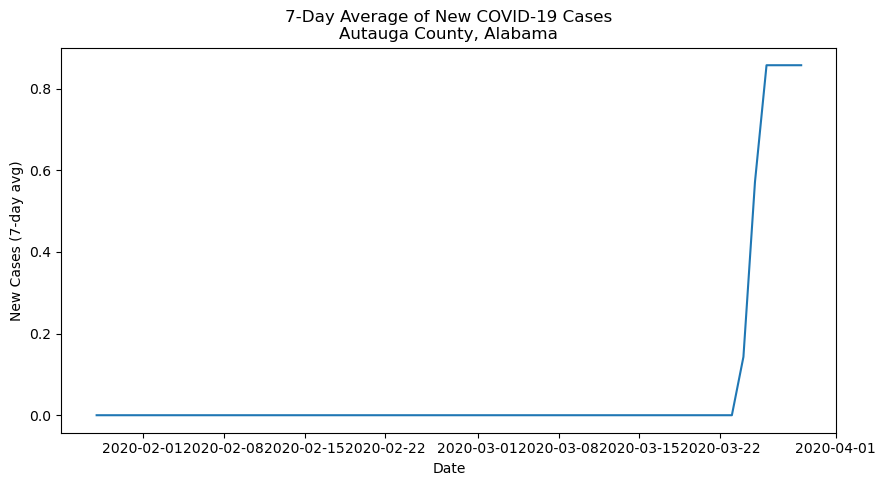

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(county_1001['date'], county_1001['new_cases_7day_avg'])
plt.title("7-Day Average of New COVID-19 Cases\nAutauga County, Alabama")
plt.xlabel("Date")
plt.ylabel("New Cases (7-day avg)")
plt.show()

In [59]:
cases_long['new_cases_clean'].describe()

count    210514.000000
mean          0.649867
std          34.828589
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       12305.000000
Name: new_cases_clean, dtype: float64

In [61]:
county_1001[['date', 'new_cases_clean', 'new_cases_7day_avg']].tail(10)

,date,new_cases_clean,new_cases_7day_avg
179094,2020-03-19,0.0,0.000000
182236,2020-03-20,0.0,0.000000
185378,2020-03-21,0.0,0.000000
188520,2020-03-23,0.0,0.000000
191662,2020-03-24,1.0,0.142857
194804,2020-03-25,3.0,0.571429
197946,2020-03-26,2.0,0.857143
201088,2020-03-27,0.0,0.857143
204230,2020-03-28,0.0,0.857143
207372,2020-03-29,0.0,0.857143


In [64]:
cases_policy = cases_long.merge(
    interventions_clean[['FIPS', 'stay_at_home']],
    on='FIPS',
    how='left'
)

In [67]:
cases_policy['after_stay_home'] = (
    cases_policy['date'] >= cases_policy['stay_at_home']
)

In [71]:
cases_policy.groupby('after_stay_home')['new_cases_7day_avg'].mean()

after_stay_home
False    0.067469
True     0.737762
Name: new_cases_7day_avg, dtype: float64

In [76]:
autauga_policy['stay_at_home'].unique()

<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]

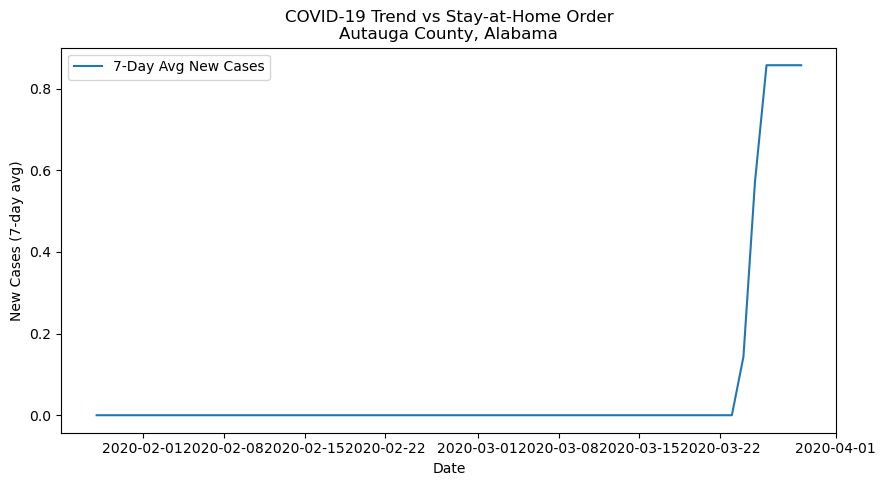

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(
    autauga_policy['date'],
    autauga_policy['new_cases_7day_avg'],
    label='7-Day Avg New Cases'
)

# Get stay-at-home date
stay_home_date = autauga_policy['stay_at_home'].iloc[0]

# Only draw the line if the date exists
if pd.notna(stay_home_date):
    plt.axvline(
        stay_home_date,
        linestyle='--',
        label='Stay-at-Home Order'
    )

plt.title("COVID-19 Trend vs Stay-at-Home Order\nAutauga County, Alabama")
plt.xlabel("Date")
plt.ylabel("New Cases (7-day avg)")
plt.legend()
plt.show()

## 6. Key Findings

- COVID-19 case growth followed clear upward trends after the first confirmed cases.
- The 7-day rolling average reduced daily reporting noise and highlighted trends.
- Case increases slowed after government intervention periods, suggesting policy impact.
- Smaller counties experienced delayed outbreaks compared to urban areas.

## 7. Conclusion

This project focused on preparing and analyzing real-world COVID-19
county-level data rather than building a predictive model. The main
challenge was transforming raw, wide-format time-series data into a
clean, analysis-ready structure.

Through this project, I demonstrated skills in data wrangling,
time-series transformation, feature engineering (daily new cases and
rolling averages), and exploratory visualization. The analysis provides
a foundation that can easily be extended into modeling or dashboard
development.

Overall, this project reflects my ability to work with messy datasets,
ask meaningful questions, and prepare data for deeper analysis.